<a href="https://colab.research.google.com/github/luckyKumar37/ML_project/blob/main/Diabetes_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import classification_report,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint



In [2]:
df = pd.read_csv('/content/diabetes_risk.csv')
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


# EDA

In [3]:
df.shape

(15000, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [6]:
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [8]:
df.dtypes.value_counts()

,count
object,9
int64,6
float64,4


In [38]:
df.isna().sum().sort_values(ascending=False)

,0
alcohol_consumption,3788
smoking_status,472
income_bracket,463
gender,0
age,0
patient_id,0
city,0
physical_activity_level,0
family_history_diabetes,0
diet_type,0


In [12]:
df.isna().mean().sort_values(ascending=False)

,0
alcohol_consumption,0.252533
smoking_status,0.031467
income_bracket,0.030867
gender,0.000000
age,0.000000
patient_id,0.000000
city,0.000000
physical_activity_level,0.000000
family_history_diabetes,0.000000
diet_type,0.000000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.nunique()

,0
patient_id,15000
age,58
gender,3
city,18
bmi,239
family_history_diabetes,2
physical_activity_level,3
diet_type,4
smoking_status,3
alcohol_consumption,3


In [43]:
df = df.drop(columns=['patient_id'])

In [44]:
num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols = df.select_dtypes(include='object').columns.to_list()



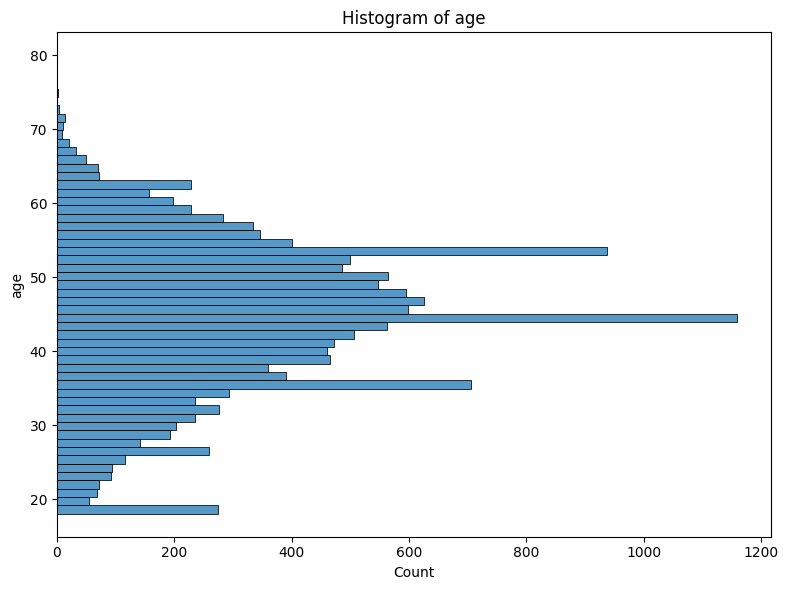

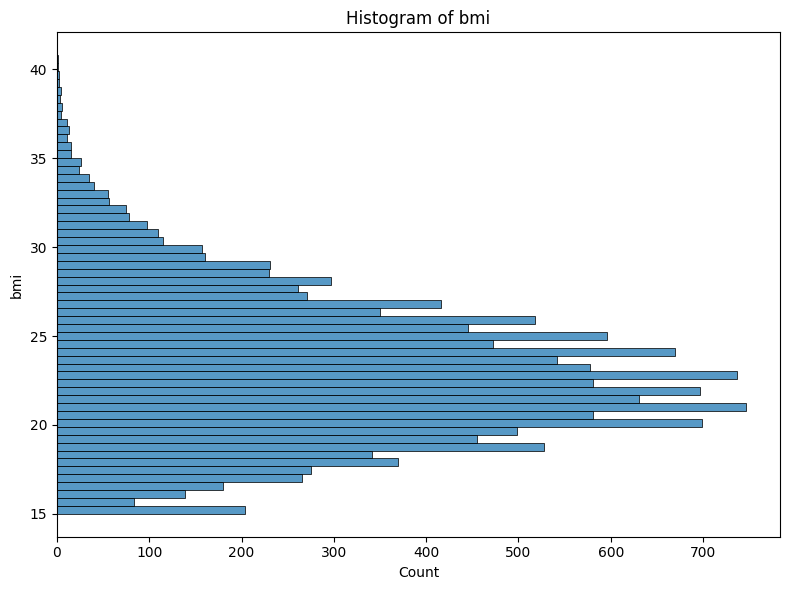

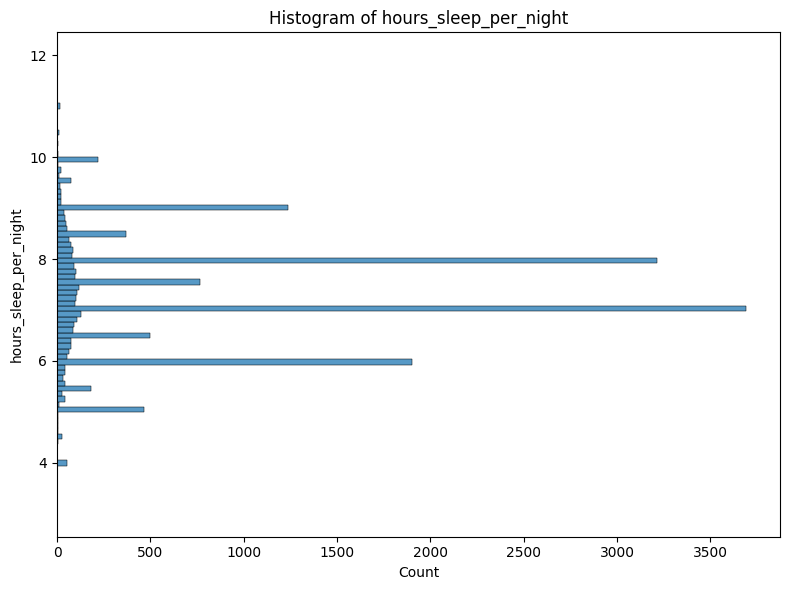

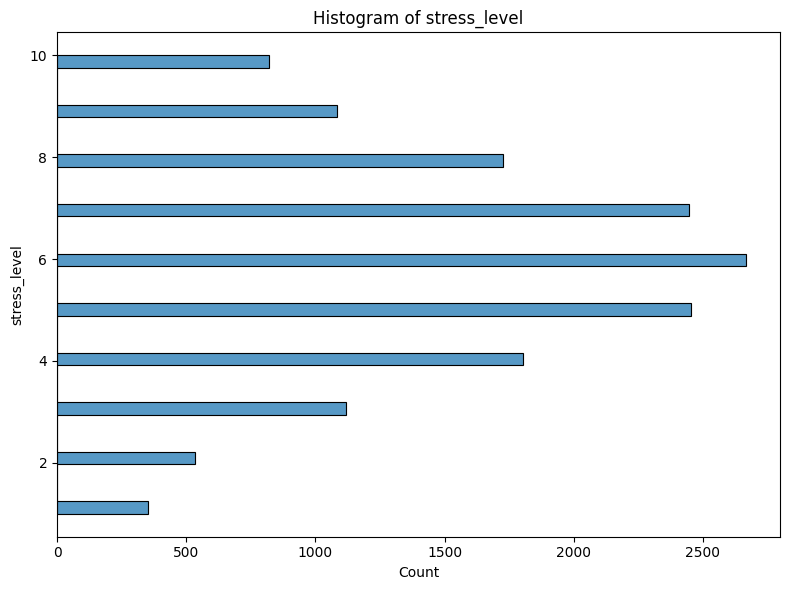

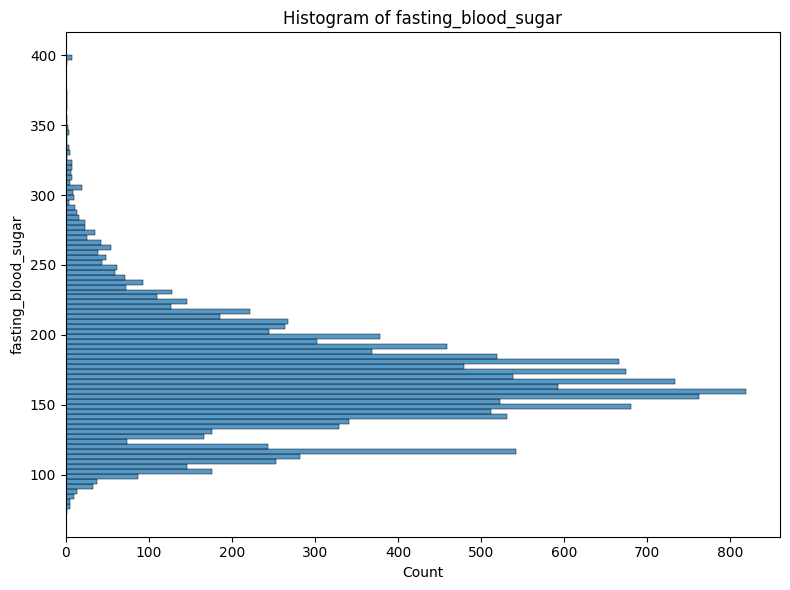

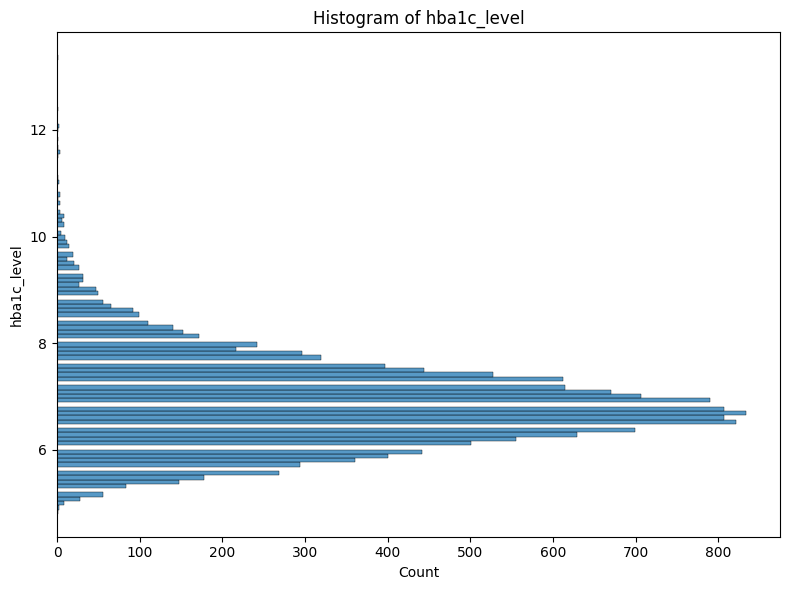

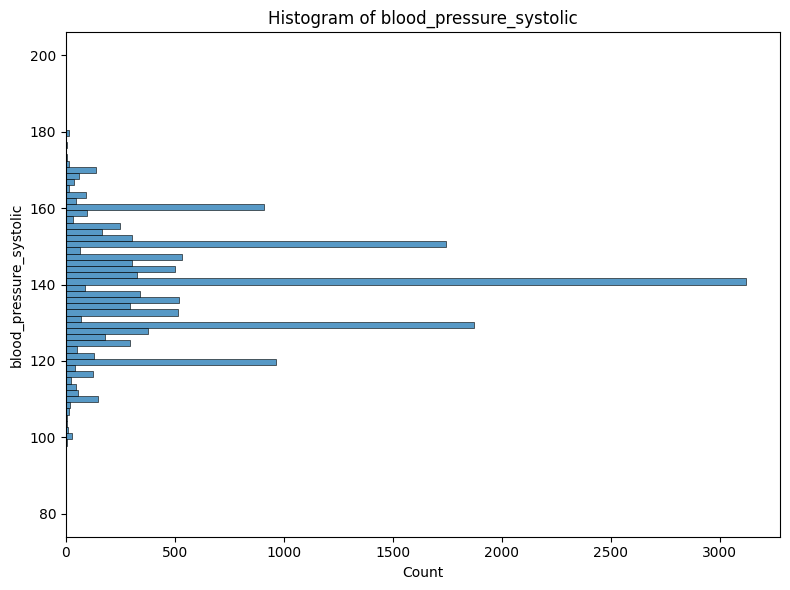

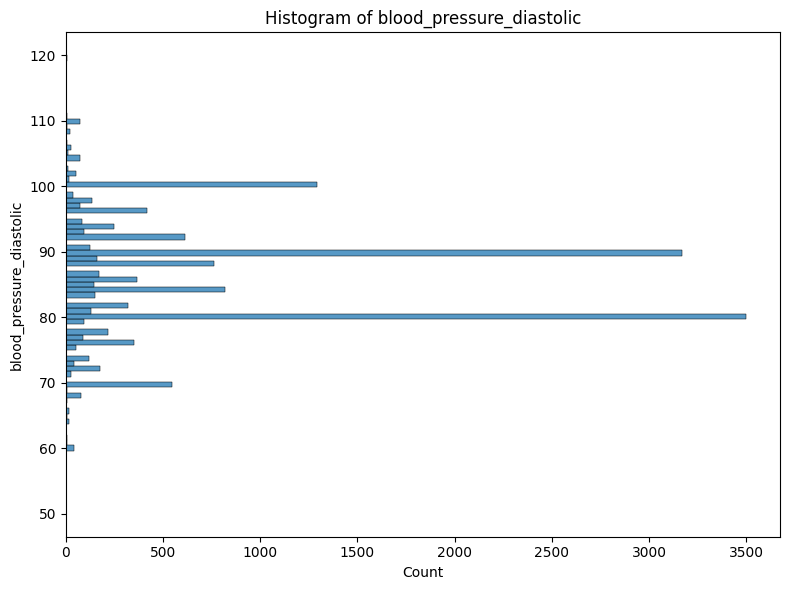

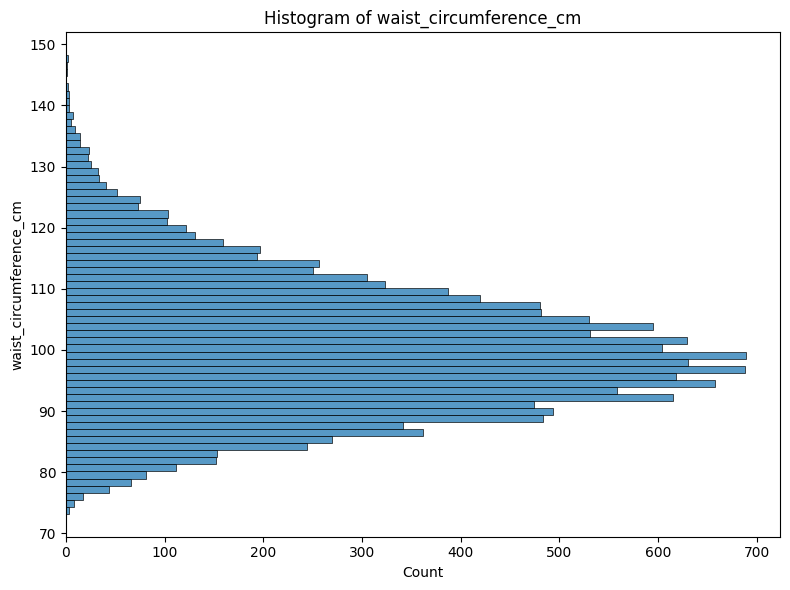

In [46]:
for col in num_cols:
  plt.figure(figsize=(8, 6))
  sns.histplot(data=df,y=col)
  plt.title(f'Histogram of {col}')
  plt.tight_layout()
  plt.show()

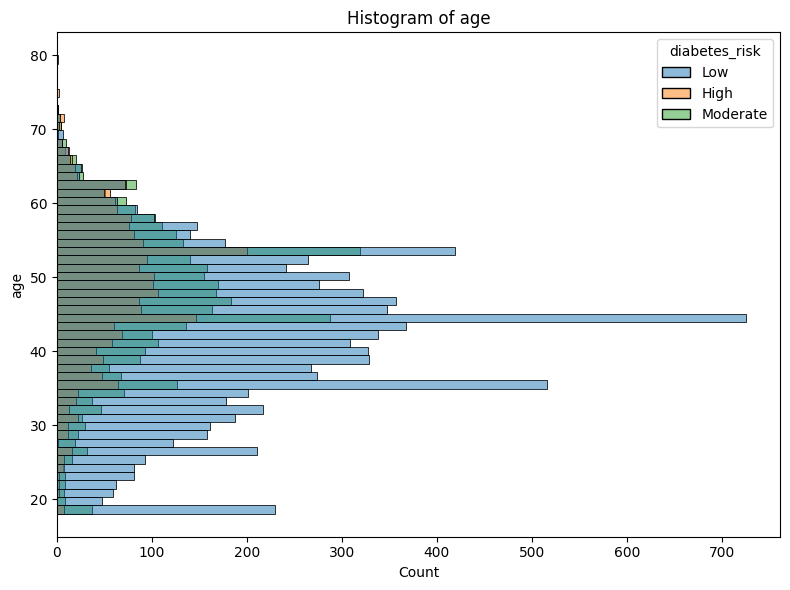

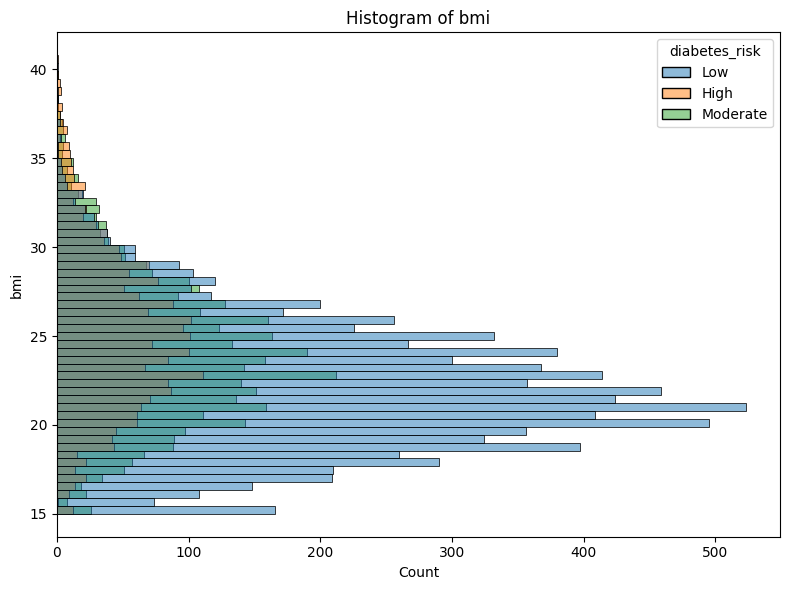

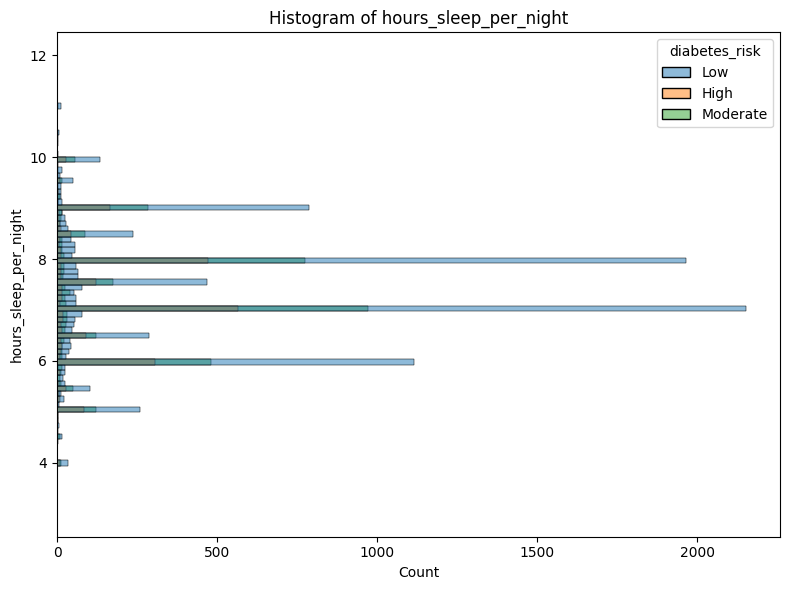

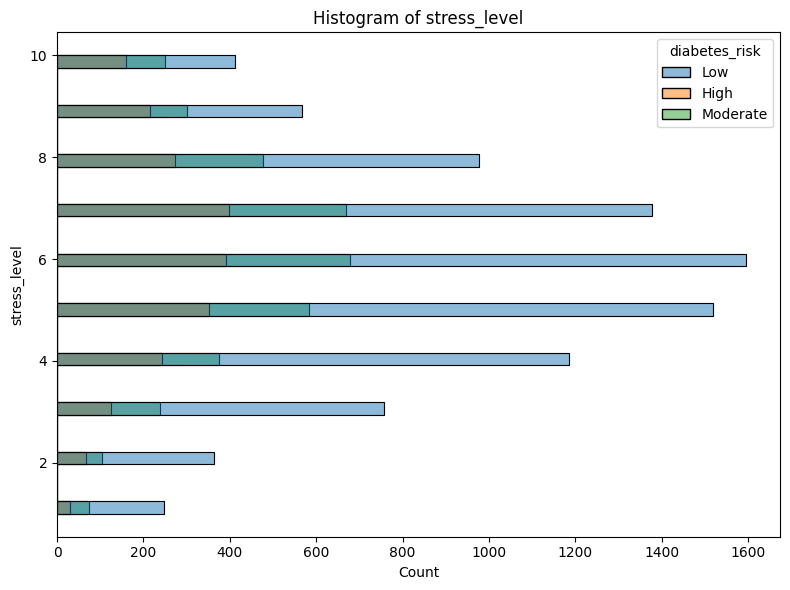

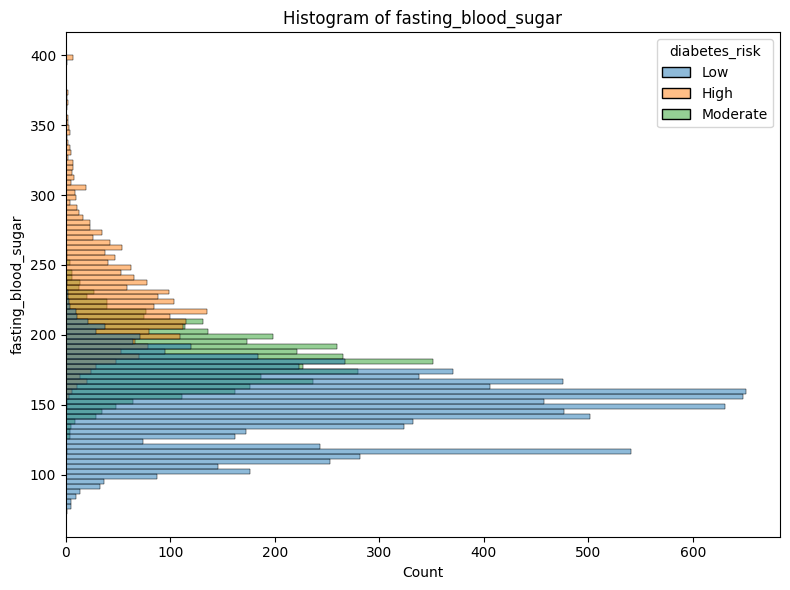

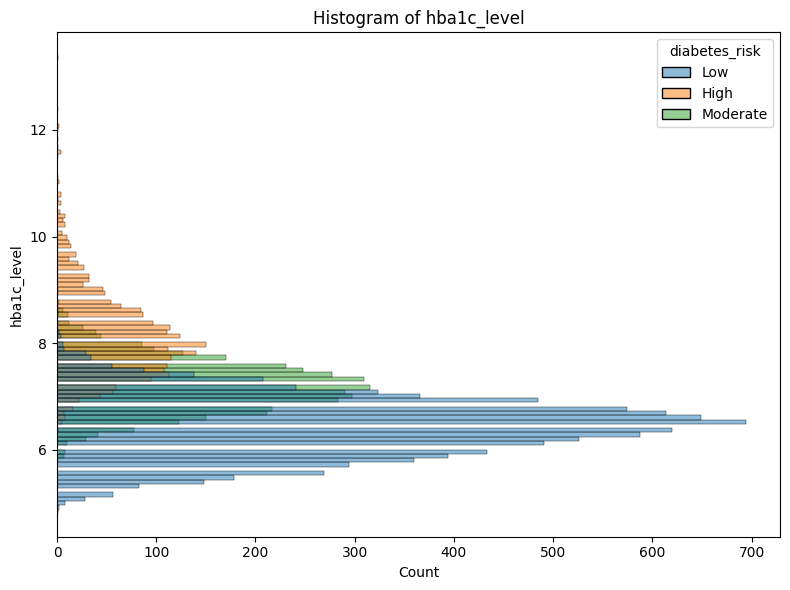

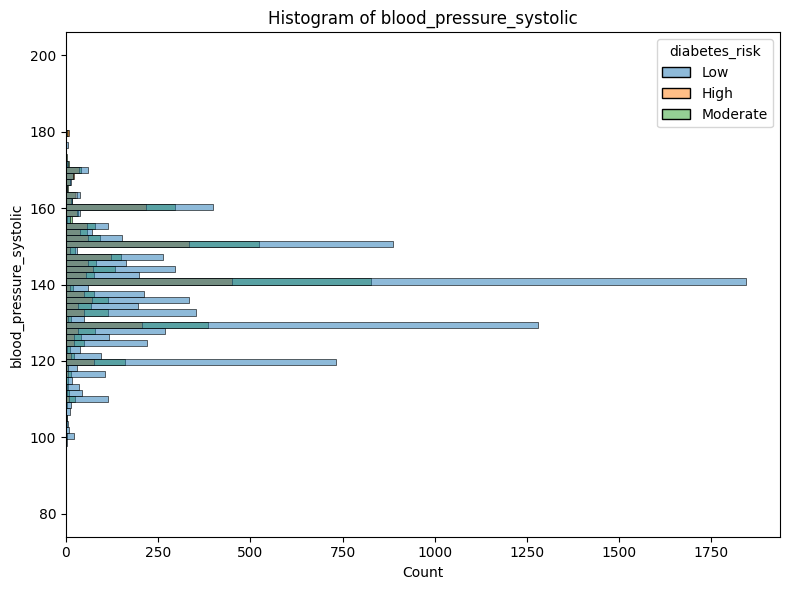

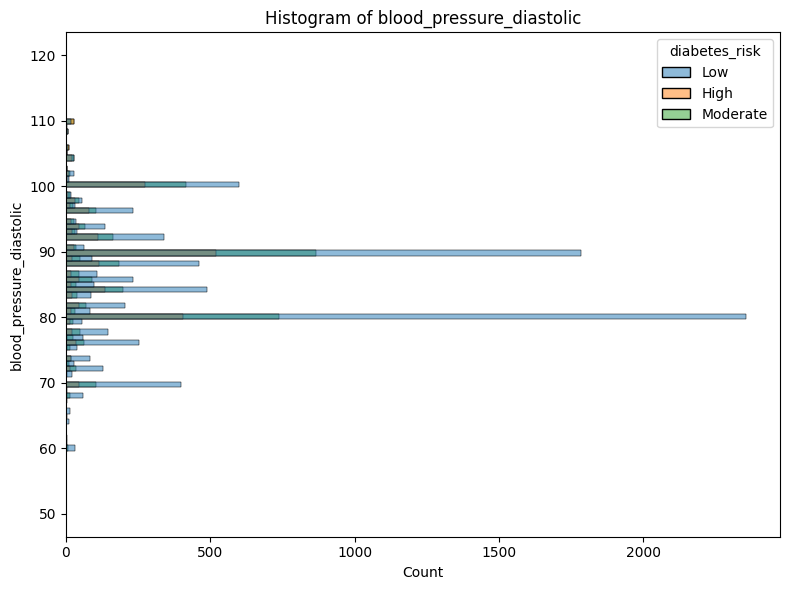

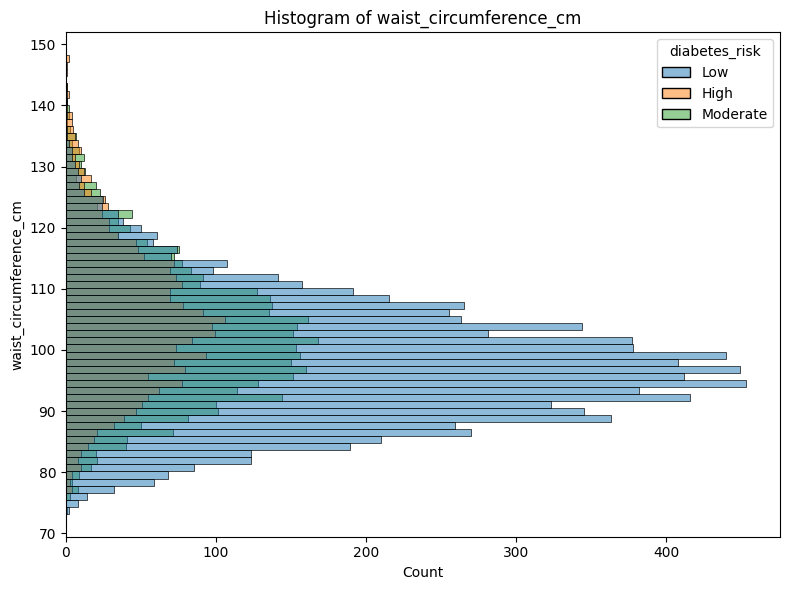

In [47]:
for col in num_cols:
  plt.figure(figsize=(8, 6))
  sns.histplot(data=df,y=col,hue='diabetes_risk')
  plt.title(f'Histogram of {col}')
  plt.tight_layout()
  plt.show()

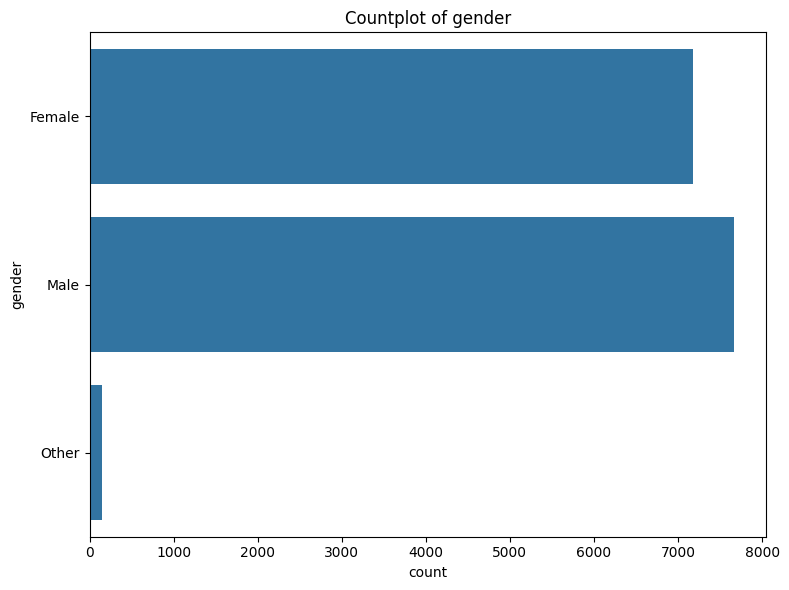

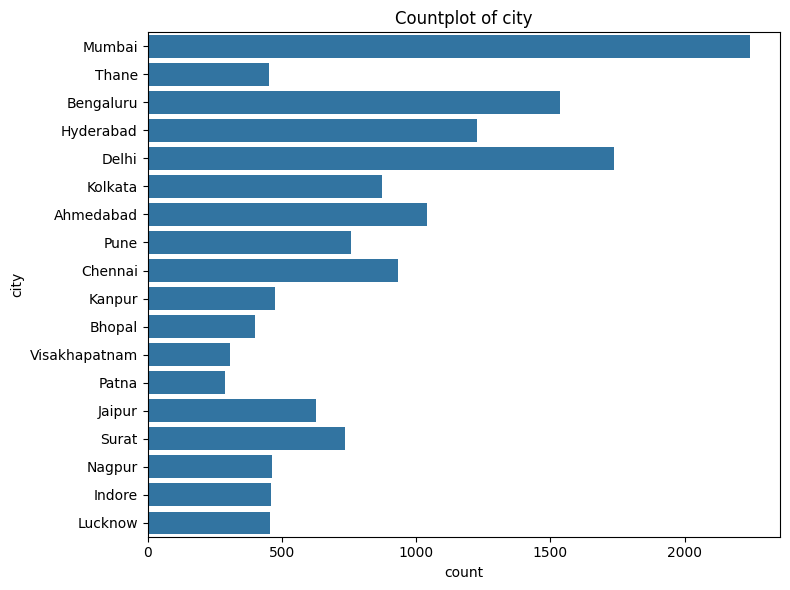

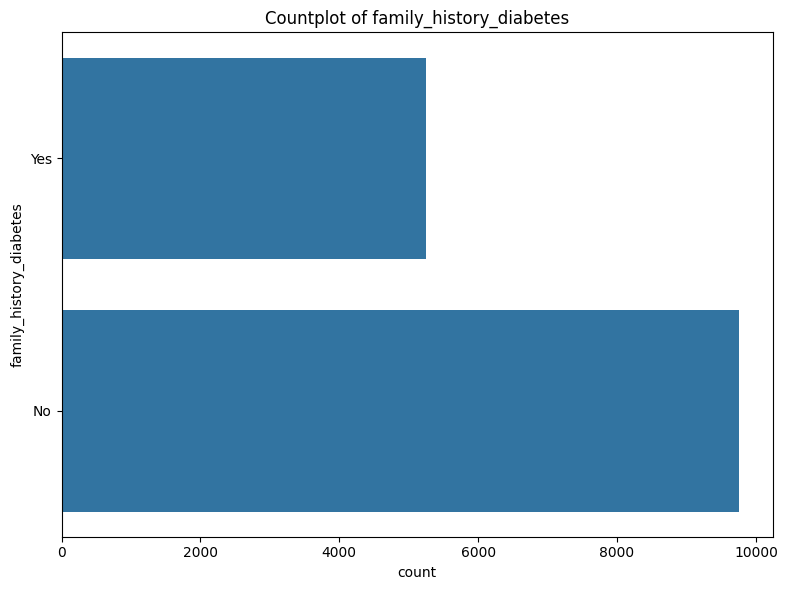

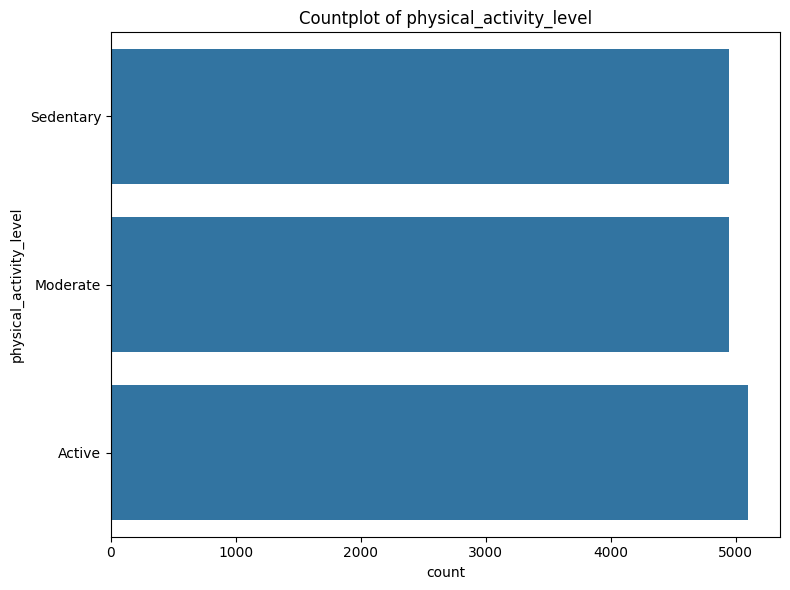

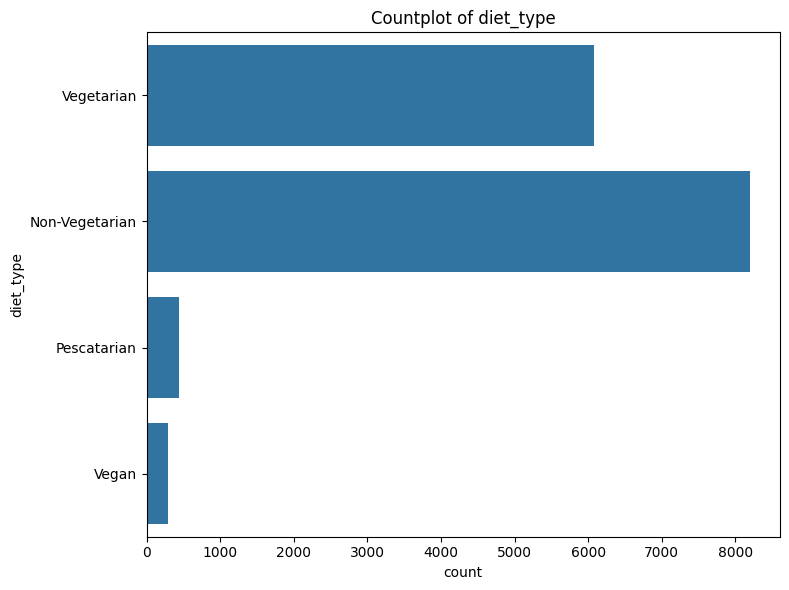

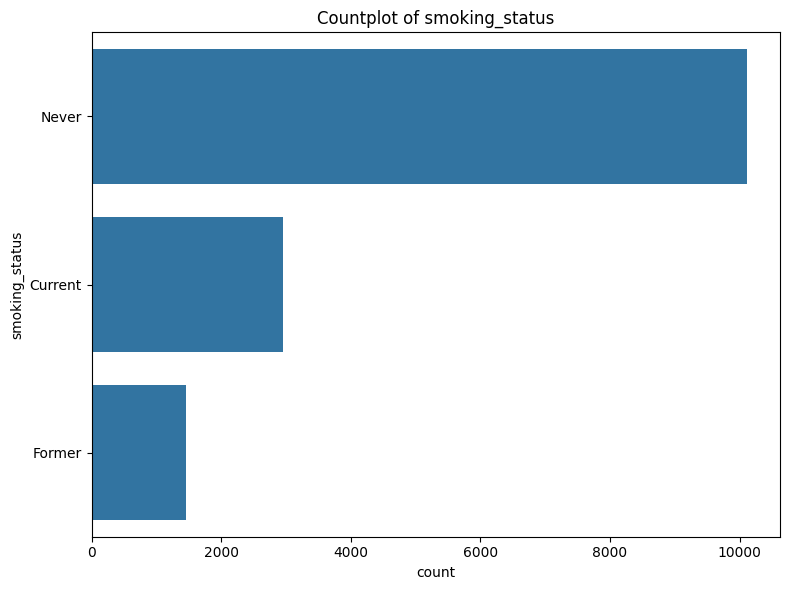

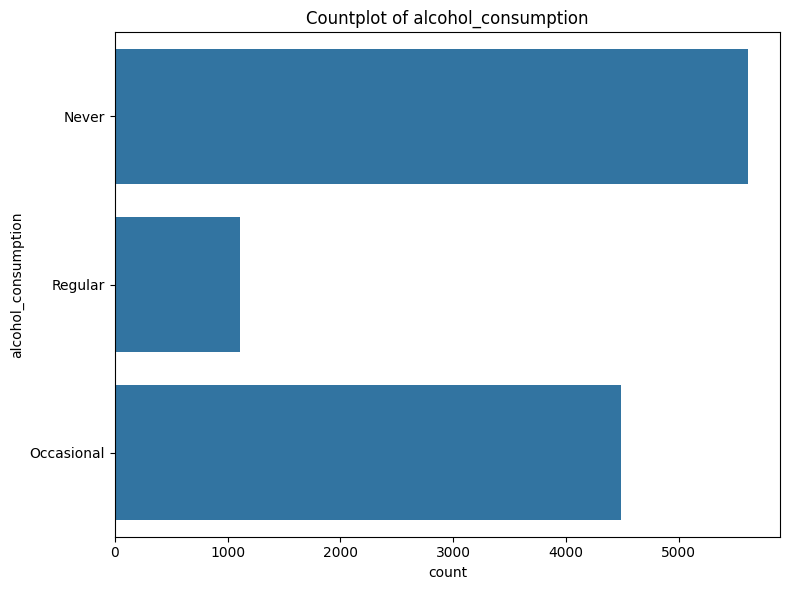

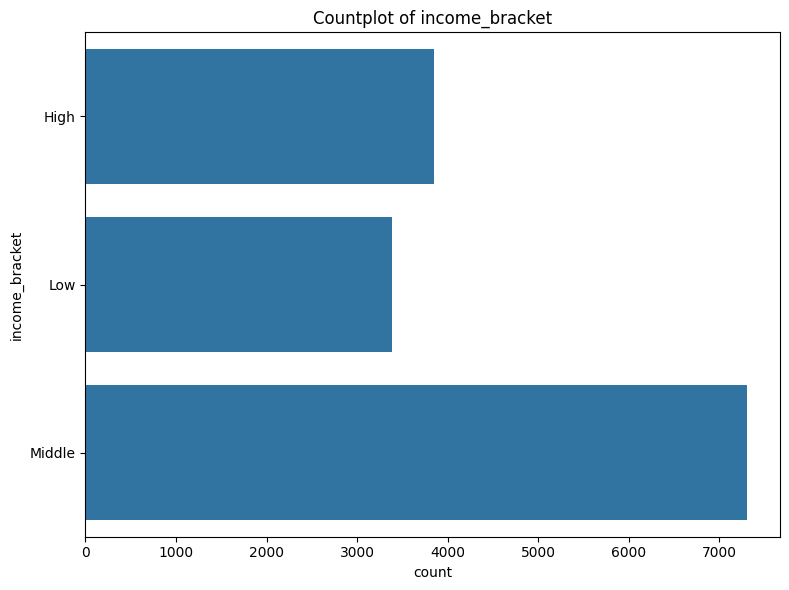

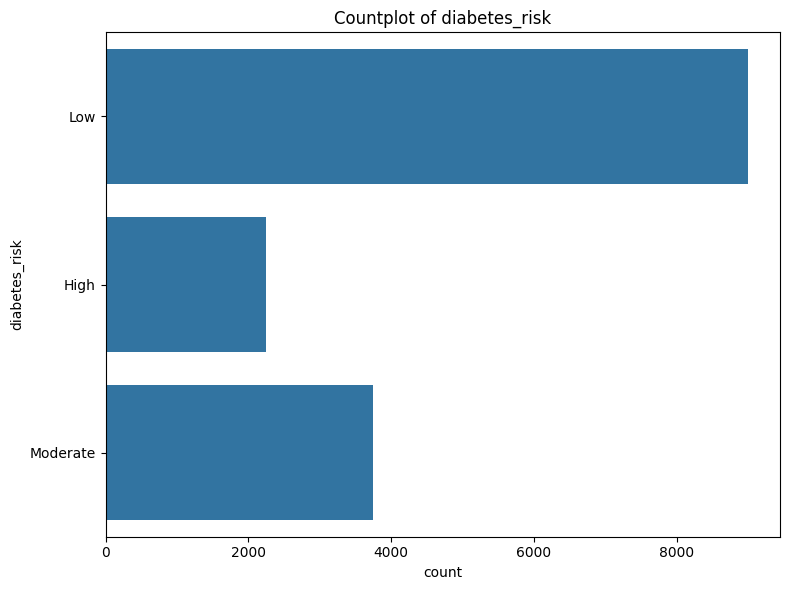

In [40]:
for col in cat_cols:
  plt.figure(figsize=(8,6))
  sns.countplot(data=df,y=col)
  plt.title(f'Countplot of {col}')
  plt.tight_layout()
  plt.show()

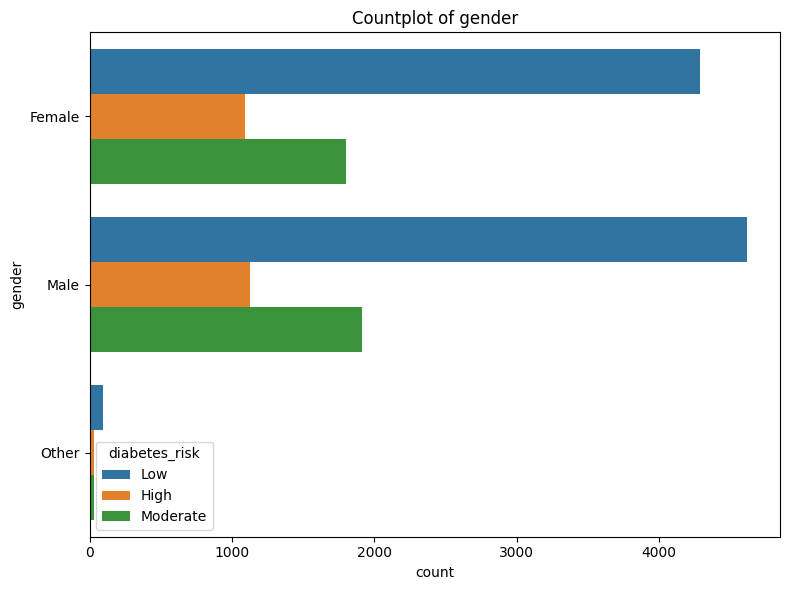

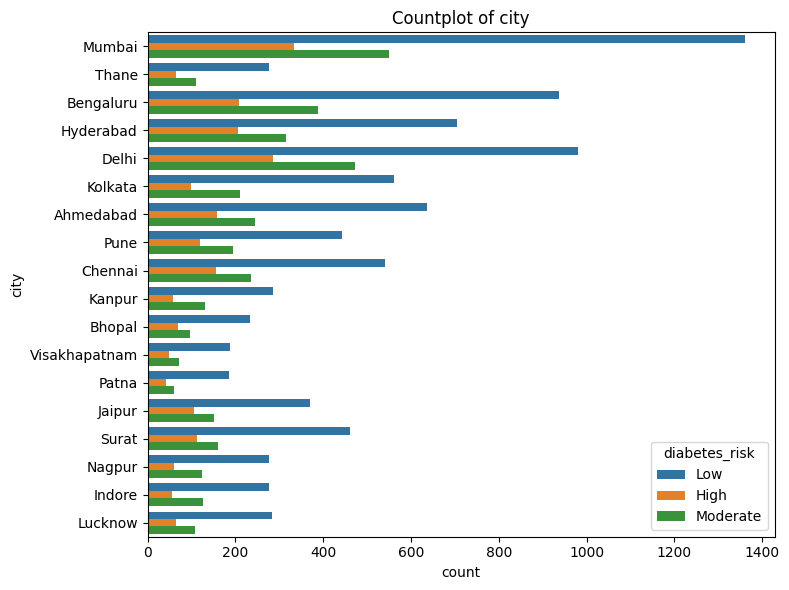

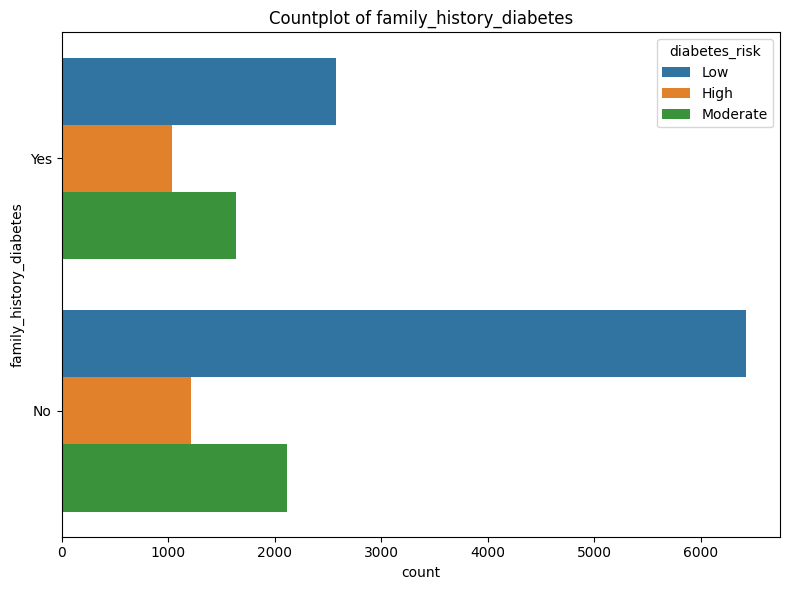

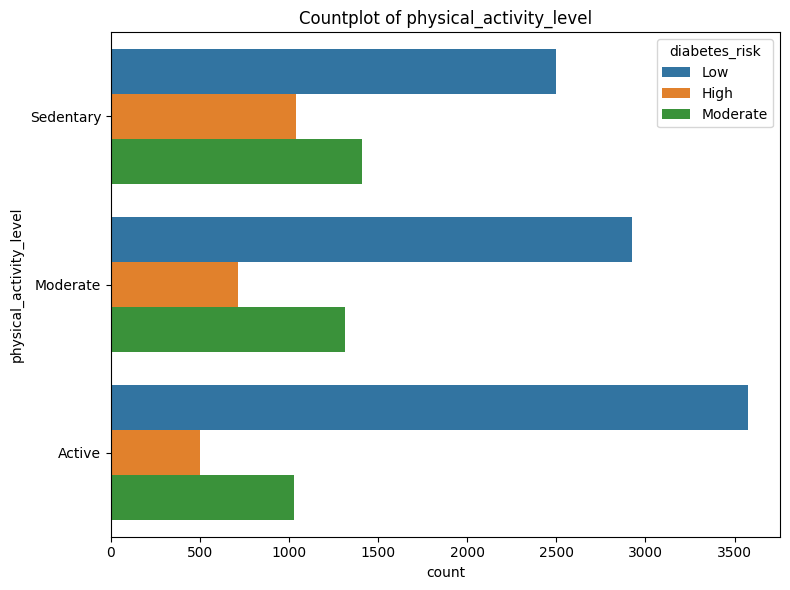

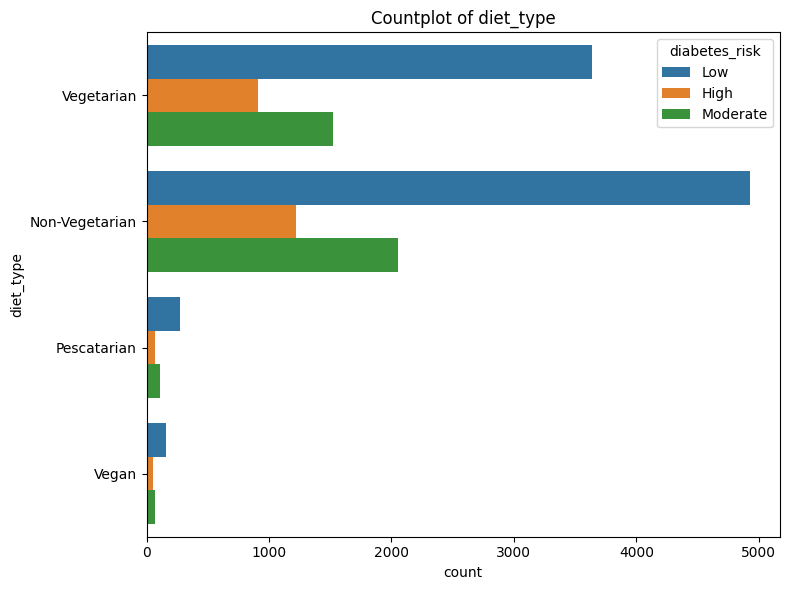

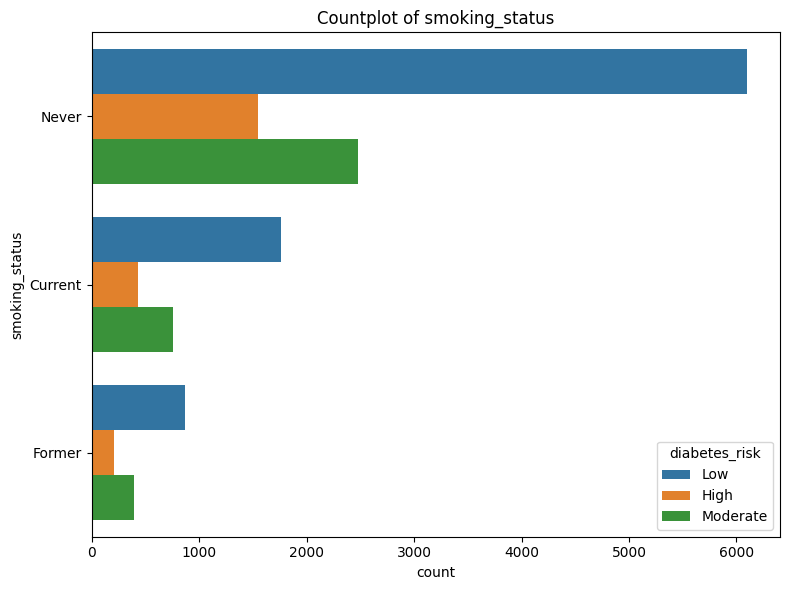

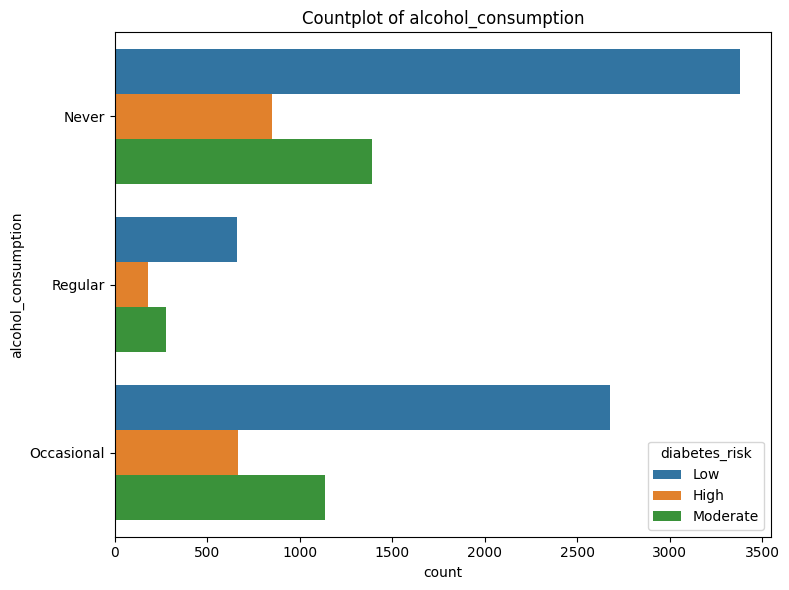

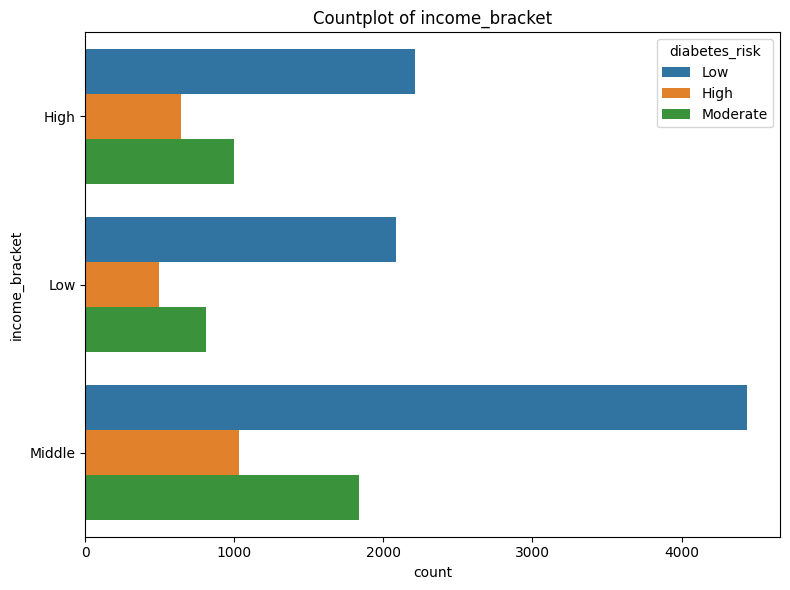

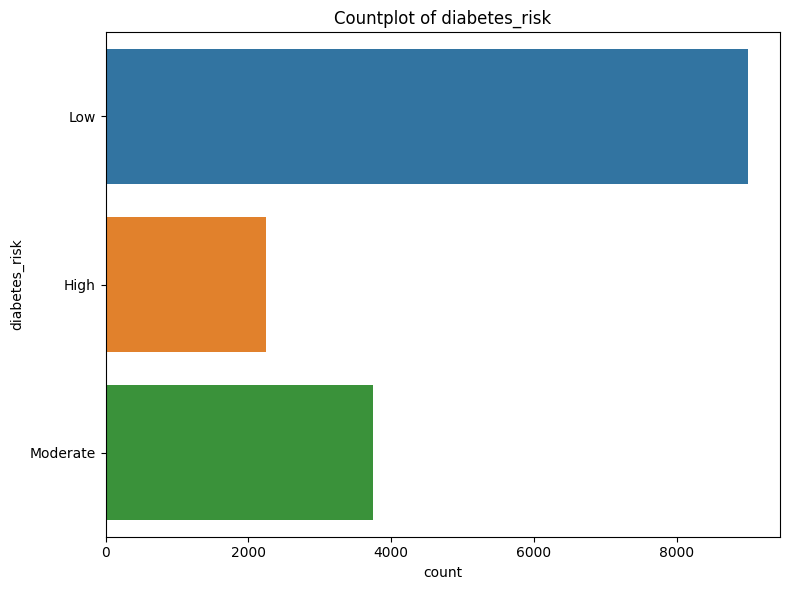

In [41]:
for col in cat_cols:
  plt.figure(figsize=(8,6))
  sns.countplot(data=df,y=col,hue='diabetes_risk')
  plt.title(f'Countplot of {col}')
  plt.tight_layout()
  plt.show()

In [30]:
from scipy import stats

z = np.abs(stats.zscore(df[num_cols].dropna()))
(z>3).sum()

np.int64(591)

<Axes: >

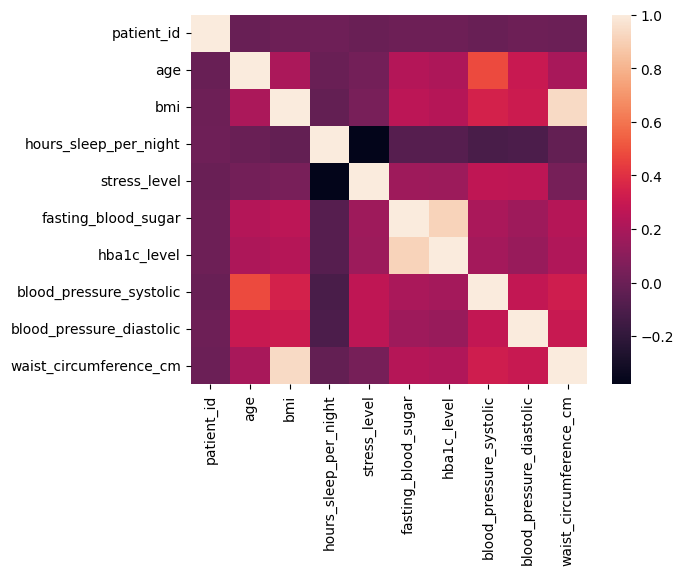

In [34]:
sns.heatmap(df[num_cols].corr())

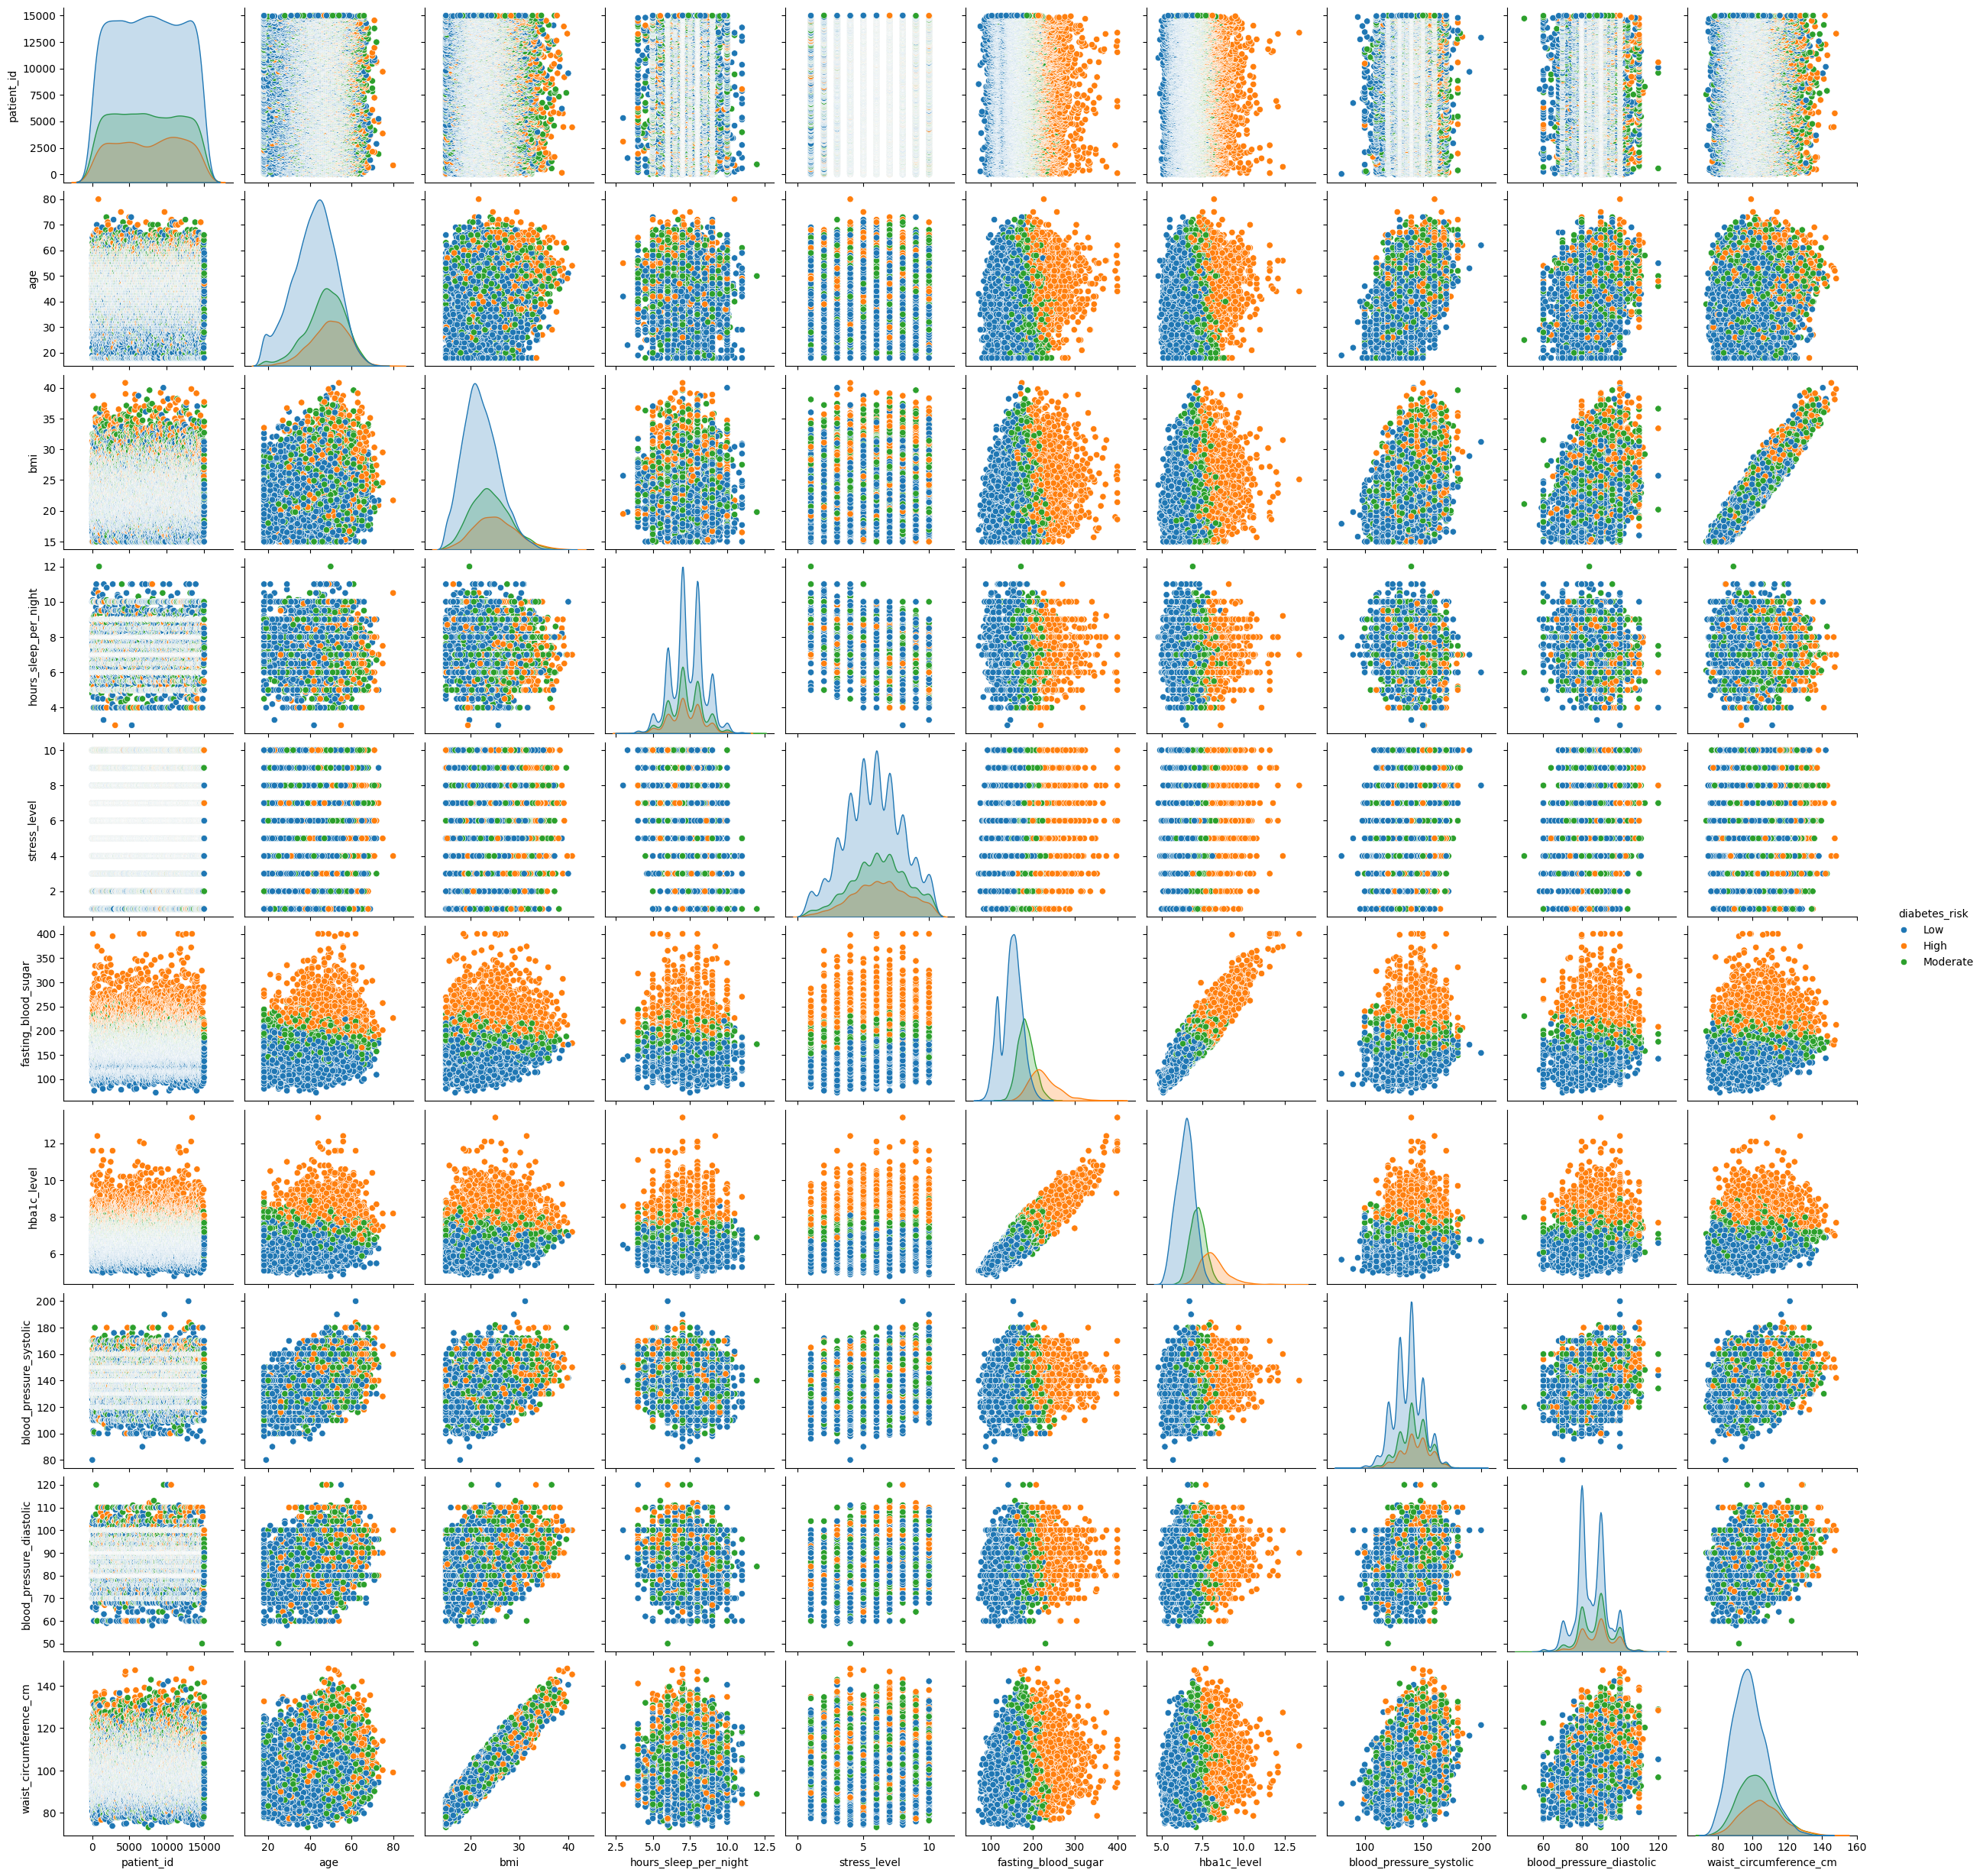

In [35]:
sns.pairplot(df[num_cols+['diabetes_risk']],hue='diabetes_risk')

<Axes: xlabel='diabetes_risk', ylabel='count'>

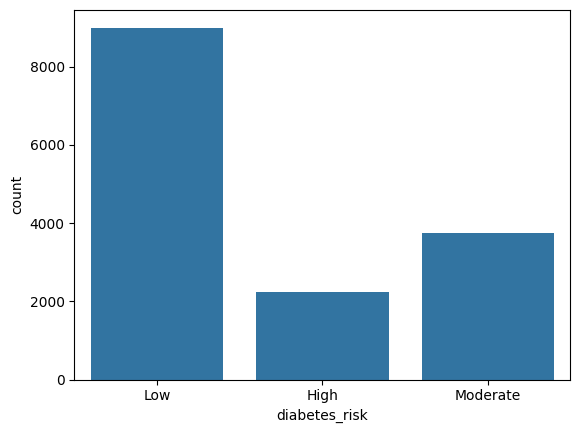

In [36]:
sns.countplot(data = df ,x = 'diabetes_risk')

# Cleaning

In [49]:
X = df.drop(columns=['diabetes_risk'])
y = df['diabetes_risk']

In [50]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [51]:
num_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.to_list()

cat_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.to_list()

In [61]:
numeric_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

preprocesser = ColumnTransformer([
    ('num',numeric_pipe,num_features),
    ('cat',cat_pipe,cat_features)
])

ful_pipe = Pipeline([
    ('preprocessing',preprocesser),
    ('model',RandomForestClassifier(random_state=42))
])

In [62]:
param_dist = {
'model__n_estimators': randint(100, 500),
'model__max_depth': randint(3, 20),
'model__min_samples_leaf': randint(1, 10),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(ful_pipe, param_dist, n_iter=30, cv=cv,
scoring='roc_auc', n_jobs=-1, random_state=42)

In [64]:
search.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'bmi',
                                                                                'hours_sleep_per_night',
                                                                                'stress_level',
                                                                                'fasting_blood_sugar',
                                                                                'hba1c_level',
                                                                                'blood_pressure_systolic',
                                                                                '...
                   param_distributions={'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fb91dd5c6b0>,
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fb91de9b650>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fb91de9ff00>},
                   random_state=42, scoring='roc_auc')

In [65]:
best_pipe = search.best_estimator_
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba, multi_class='ovr', labels=best_pipe.classes_))

              precision    recall  f1-score   support

        High       0.82      0.68      0.75       450
         Low       0.84      0.92      0.88      1800
    Moderate       0.59      0.50      0.54       750

    accuracy                           0.78      3000
   macro avg       0.75      0.70      0.72      3000
weighted avg       0.77      0.78      0.77      3000

ROC-AUC: 0.9077337265795208
